In [21]:
# ============================================================
#  Project Name: brandalyze
#  File: tweet_analysis.ipynb
#  Author: dngi (https://twitter.com/_dngi)
#  Created: <2026-02-13>
#  
#  Copyright (c) 2026 Dom G. (https://twitter.com/_dngi)
#  All rights reserved.
#
#  This notebook and its contents are confidential and
#  proprietary. Unauthorized copying, distribution,
#  modification, or use is strictly prohibited.
# ============================================================

# Brandalyze Viral Tweet Analysis

In [22]:
# imports
import json
import pandas as pd
import numpy as np

## Data Loading/Exploration

In [23]:
# load dataset
with open('labeled-viral-tweets.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# convert to DataFrame for easier analysis
df = pd.DataFrame(data)

# basic info
print(f"Total tweets: {len(df)}")
print(f"Labeled tweets: {df['labels'].notna().sum()}")

# preview
df.head()

Total tweets: 6993
Labeled tweets: 6993


,type,id,url,twitterUrl,text,fullText,source,retweetCount,replyCount,likeCount,...,entities,isRetweet,isQuote,quote,media,isConversationControlled,viralityTier,viralityScore,labels,possiblySensitive
0,tweet,1991989635380396137,https://x.com/Ryanair/status/1991989635380396137,https://twitter.com/Ryanair/status/19919896353...,we would never give out headphones,we would never give out headphones,Twitter for iPhone,20955,3887,462344,...,"{'hashtags': [], 'symbols': [], 'timestamps': ...",False,True,"{'type': 'tweet', 'id': '1991952186683838622',...",[],False,ultra-viral,462344,"{'format': 'shitpost', 'hookQuality': 'none', ...",NaN
1,tweet,1942584467719061627,https://x.com/jaboukie/status/1942584467719061627,https://twitter.com/jaboukie/status/1942584467...,then explain how i'm married to the game,then explain how i'm married to the game,Twitter Web App,37202,576,375251,...,"{'hashtags': [], 'symbols': [], 'timestamps': ...",False,True,"{'type': 'tweet', 'id': '1942229032999002557',...",[],False,ultra-viral,375251,"{'format': 'shitpost', 'hookQuality': 'none', ...",NaN
2,tweet,1981032078876475584,https://x.com/dhaboy01/status/1981032078876475584,https://twitter.com/dhaboy01/status/1981032078...,You say? https://t.co/qaes7hI8HB,You say? https://t.co/qaes7hI8HB,Twitter for iPhone,25337,534,307616,...,"{'hashtags': [], 'media': [{'display_url': 'pi...",False,True,"{'type': 'tweet', 'id': '1980990400254075352',...",[https://pbs.twimg.com/media/G34KK2KXEAAJVPE.jpg],False,ultra-viral,307616,"{'format': 'shitpost', 'hookQuality': 'none', ...",False
3,tweet,1957877191624257997,https://x.com/ZyMazza/status/1957877191624257997,https://twitter.com/ZyMazza/status/19578771916...,Why does it only work for 8 hours like a human...,Why does it only work for 8 hours like a human...,Twitter for iPhone,9009,959,280318,...,"{'hashtags': [], 'symbols': [], 'timestamps': ...",False,True,"{'type': 'tweet', 'id': '1957842048930734483',...",[],False,ultra-viral,280318,"{'format': 'shitpost', 'hookQuality': 'none', ...",NaN
4,tweet,2006546040179273960,https://x.com/NoContextHumans/status/200654604...,https://twitter.com/NoContextHumans/status/200...,He waved like the president of the us 😂https:/...,He waved like the president of the us 😂https:/...,TweetDeck Web App,5570,209,254074,...,"{'hashtags': [], 'media': [{'display_url': 'pi...",False,False,NaN,[https://pbs.twimg.com/amplify_video_thumb/200...,False,ultra-viral,254074,"{'format': 'shitpost', 'hookQuality': 'none', ...",False


## Label Data Extraction

In [24]:
# extract label fields into separate columns
df['format'] = df['labels'].apply(lambda x: x.get('format') if isinstance(x, dict) else None)
df['hookQuality'] = df['labels'].apply(lambda x: x.get('hookQuality') if isinstance(x, dict) else None)
df['closerType'] = df['labels'].apply(lambda x: x.get('closerType') if isinstance(x, dict) else None)

# check distribution
print("\nFormat distribution:")
print(df['format'].value_counts())
print("\nHook quality distribution:")
print(df['hookQuality'].value_counts())
print("\nCloser type distribution:")
print(df['closerType'].value_counts())


Format distribution:
format
informative      2088
shitpost         1628
opinion          1221
entertaining      694
story             430
inspirational     309
question          226
news              211
educational       185
unknown             1
Name: count, dtype: int64

Hook quality distribution:
hookQuality
none       4476
weak       1102
medium      707
strong      706
unknown       2
Name: count, dtype: int64

Closer type distribution:
closerType
none           5050
statement      1353
cliffhanger     313
question        148
cta             126
unknown           3
Name: count, dtype: int64


## Engagement Metric Extraction
- likes, retweets, views bookmarks
- calculate engagement rates
- add virality tiers

In [25]:
df['likes'] = df['likeCount']
df['retweets'] = df['retweetCount']
df['replies'] = df['replyCount']
df['views'] = df['viewCount']
df['bookmarks'] = df['bookmarkCount']

df['total_engagement'] = df['likes'] + df['retweets'] + df['replies'] + df['bookmarks']
df['engagement_rate'] = (df['total_engagement'] / df['views']) * 100

print(df['viralityTier'].value_counts())

viralityTier
viral           2293
very-viral      1740
semi-viral      1501
ultra-viral      692
highly-viral     590
standard         177
Name: count, dtype: int64


## Author Metric Extraction
- get follower counts, following, bio
- categorize accounts by size
- extract tweet type (e.g. tweet, quote)

In [26]:
df['author_username'] = df['author'].apply(lambda x: x.get('userName'))
df['author_followers'] = df['author'].apply(lambda x: x.get('followers'))
df['author_bio'] = df['author'].apply(lambda x: x.get('description'))

# categorize by follower count
def categorize_account_size(followers):
    if followers < 5000:
        return 'micro'
    elif followers < 50000:
        return 'mid'
    else:
        return 'macro'

df['account_size'] = df['author_followers'].apply(categorize_account_size)

# extract tweet type
df['is_quote'] = df['isQuote']
df['is_reply'] = df['isReply']
df['tweet_type'] = df.apply(lambda x: 'quote' if x['is_quote'] else ('reply' if x['is_reply'] else 'tweet'), axis=1)

## Text Analysis Prep
- extract tweet text
- calculate text_length
- check for media presence
- count hashtags/mentions/URLs

In [27]:
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

df['has_media'] = df['extendedEntities'].apply(lambda x: bool(x.get('media', [])) if isinstance(x, dict) else False)
df['media_type'] = df['extendedEntities'].apply(
    lambda x: x.get('media', [{}])[0].get('type') if isinstance(x, dict) and x.get('media') else None
)

# Entity counts
df['hashtag_count'] = df['entities'].apply(lambda x: len(x.get('hashtags', [])) if isinstance(x, dict) else 0)
df['mention_count'] = df['entities'].apply(lambda x: len(x.get('user_mentions', [])) if isinstance(x, dict) else 0)
df['url_count'] = df['entities'].apply(lambda x: len(x.get('urls', [])) if isinstance(x, dict) else 0)

## Correlation Analysis
- format vs engagement
- hook quality vs virality
- closer type vs engagement
- account size impact

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# format performance
format_stats = df.groupby('format').agg({
    'likes': 'mean',
    'total_engagement': 'mean',
    'engagement_rate': 'mean'
}).round(2)

print("Average engagement by format:")
print(format_stats)

# hook quality impact
hook_stats = df.groupby('hookQuality').agg({
    'likes': 'mean',
    'views': 'mean',
    'engagement_rate': 'mean'
}).round(2)

print("\nEngagement by hook quality:")
print(hook_stats)

Average engagement by format:
                  likes  total_engagement  engagement_rate
format                                                    
educational     5885.53          10520.50             2.23
entertaining    5360.23           6287.48             3.10
informative     3200.26           4884.84             2.36
inspirational   4556.70           5849.20             3.43
news            4737.08           6147.04             3.33
opinion         4447.46           5522.54             2.64
question        3686.70           4744.04             2.06
shitpost        8406.18           9636.85             2.99
story           3974.66           7785.62             1.28
unknown        30482.00          32615.00             2.37

Engagement by hook quality:
                likes       views  engagement_rate
hookQuality                                       
medium        5279.17   652277.34             2.34
none          5069.57   469339.92             2.83
strong        5651.42   88016

## Visualizations
- bar charts for format/hook
- box plots for engagement by category
- heatmaps for correlations
- scatter plot for relationships

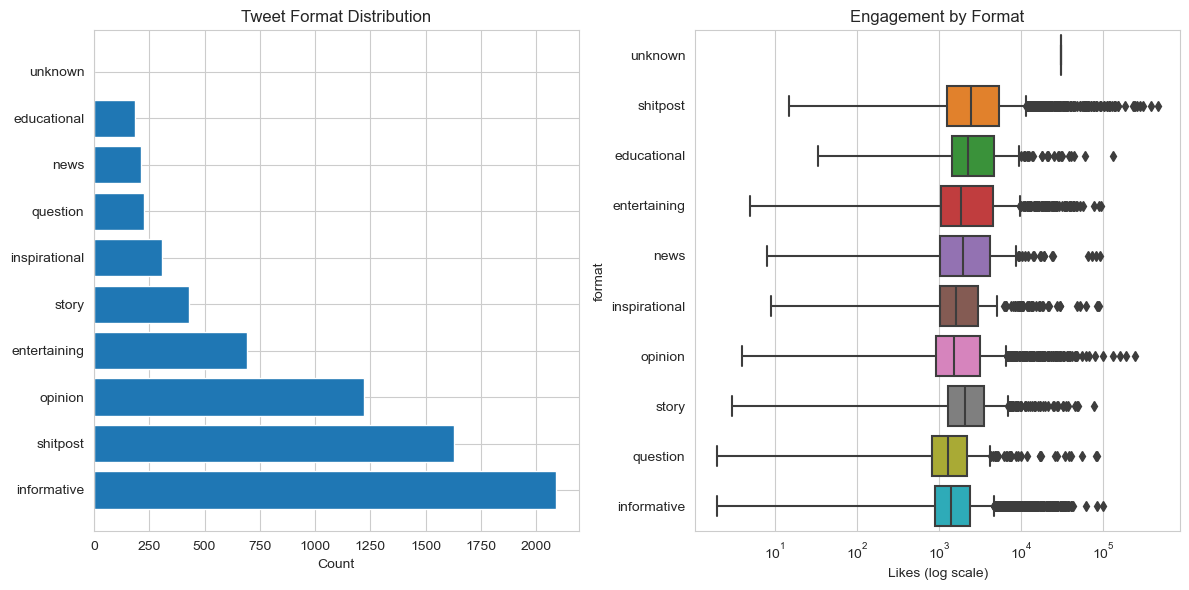

In [29]:
# set style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# format distribution with engagement
plt.subplot(1, 2, 1)
format_counts = df['format'].value_counts()
plt.barh(format_counts.index, format_counts.values)
plt.xlabel('Count')
plt.title('Tweet Format Distribution')

# Engagement by format
plt.subplot(1, 2, 2)
sns.boxplot(data=df, y='format', x='likes', order=format_stats.sort_values('likes', ascending=False).index)
plt.xscale('log')
plt.xlabel('Likes (log scale)')
plt.title('Engagement by Format')

plt.tight_layout()
plt.show()

## Key Insights Discovery
- what formats perform the best?
- does hook quality matter?
- do closers impact engagement?
- account size vs format effectiveness
- media impact on virality

In [30]:
# top performing combos
top_combos = df.groupby(['format', 'hookQuality', 'closerType']).agg({
    'likes': 'mean',
    'total_engagement': 'mean',
    'id': 'count'
}).rename(columns={'id': 'count'})

top_combos = top_combos[top_combos['count'] >= 10]
top_combos = top_combos.sort_values('likes', ascending=False).head(10)

print("Top 10 performing label combinations:")
print(top_combos)

Top 10 performing label combinations:
                                            likes  total_engagement  count
format       hookQuality closerType                                       
shitpost     weak        none        63589.200000      71859.333333     15
opinion      medium      none        28036.769231      34196.384615     13
             strong      none        19380.266667      25631.466667     15
educational  strong      statement   15927.578947      25580.631579     19
story        strong      cta         15217.100000      32584.500000     10
entertaining weak        none        11887.673913      14078.391304     46
news         medium      none        10252.000000      11787.545455     11
informative  strong      cta         10149.214286      17647.071429     14
opinion      weak        none         9733.816667      11463.550000     60
story        medium      none         9365.894737      16256.263158     19


### Media Impact Analysis
Analyzing the role of media in viral tweets

In [31]:
# Media presence ratio
media_ratio = df['has_media'].value_counts(normalize=True) * 100
print("Media presence in viral tweets:")
print(f"With media: {media_ratio.get(True, 0):.1f}%")
print(f"Without media: {media_ratio.get(False, 0):.1f}%")

# Average engagement: media vs no media
media_engagement = df.groupby('has_media').agg({
    'likes': 'mean',
    'total_engagement': 'mean',
    'engagement_rate': 'mean'
}).round(2)

print("\nEngagement by media presence:")
print(media_engagement)

# Media types breakdown
print("\nMedia type distribution:")
print(df[df['has_media']]['media_type'].value_counts())

Media presence in viral tweets:
With media: 53.5%
Without media: 46.5%

Engagement by media presence:
             likes  total_engagement  engagement_rate
has_media                                            
False      5126.55           6455.02             2.46
True       5056.25           6817.99             2.73

Media type distribution:
media_type
photo           2552
video           1102
animated_gif      88
Name: count, dtype: int64


### Media as Compensation for Weak/No Hooks and Closers

In [32]:
# When posts had weak/no hook or no closer, was there media?
weak_hook_no_closer = df[(df['hookQuality'].isin(['weak', 'none'])) & (df['closerType'] == 'none')]
print(f"Tweets with weak/no hook AND no closer: {len(weak_hook_no_closer)}")
print(f"Of those, {weak_hook_no_closer['has_media'].sum()} had media ({weak_hook_no_closer['has_media'].mean()*100:.1f}%)")

# Short tweets with media
short_tweets = df[df['text_length'] < 50]
print(f"\nTweets with <50 characters: {len(short_tweets)}")
print(f"Of those, {short_tweets['has_media'].sum()} had media ({short_tweets['has_media'].mean()*100:.1f}%)")

# Cross-tab: Hook quality vs Media presence
hook_media_crosstab = pd.crosstab(df['hookQuality'], df['has_media'], normalize='index') * 100
print("\nMedia presence % by hook quality:")
print(hook_media_crosstab.round(1))

Tweets with weak/no hook AND no closer: 4613
Of those, 2512 had media (54.5%)

Tweets with <50 characters: 863
Of those, 453 had media (52.5%)

Media presence % by hook quality:
has_media    False  True 
hookQuality              
medium        44.7   55.3
none          46.6   53.4
strong        40.8   59.2
unknown        0.0  100.0
weak          51.0   49.0


### Shitpost Analysis
Do shitposts follow traditional hook/body/closer patterns?

In [33]:
# Shitpost hook/closer patterns
shitposts = df[df['format'] == 'shitpost']

print(f"Total shitposts: {len(shitposts)}")
print(f"\nHook quality distribution in shitposts:")
print(shitposts['hookQuality'].value_counts(normalize=True) * 100)
print(f"\nCloser type distribution in shitposts:")
print(shitposts['closerType'].value_counts(normalize=True) * 100)

# Compare shitpost engagement to other formats
shitpost_vs_others = df.groupby(df['format'] == 'shitpost').agg({
    'likes': 'mean',
    'total_engagement': 'mean',
    'engagement_rate': 'mean'
}).round(2)
shitpost_vs_others.index = ['Other Formats', 'Shitpost']
print("\nShitpost performance vs others:")
print(shitpost_vs_others)

Total shitposts: 1628

Hook quality distribution in shitposts:
hookQuality
none       97.420147
weak        1.535627
strong      0.614251
medium      0.368550
unknown     0.061425
Name: proportion, dtype: float64

Closer type distribution in shitposts:
closerType
none           98.587224
statement       0.859951
cliffhanger     0.245700
question        0.245700
unknown         0.061425
Name: proportion, dtype: float64

Shitpost performance vs others:
                 likes  total_engagement  engagement_rate
Other Formats  4082.32           5742.66             2.49
Shitpost       8406.18           9636.85             2.99


### Account Size Impact on Format Effectiveness

In [34]:
# Does format effectiveness vary by account size?
format_by_size = df.groupby(['account_size', 'format']).agg({
    'likes': 'mean',
    'engagement_rate': 'mean',
    'id': 'count'
}).rename(columns={'id': 'count'})

# Filter for formats with at least 5 examples per account size
format_by_size = format_by_size[format_by_size['count'] >= 5]
format_by_size = format_by_size.sort_values(['account_size', 'likes'], ascending=[True, False])

print("Format performance by account size:")
print(format_by_size)

# Do micro accounts need stronger hooks than macro accounts?
hook_by_size = df.groupby(['account_size', 'hookQuality']).agg({
    'likes': 'mean',
    'engagement_rate': 'mean'
}).round(2)

print("\nHook quality impact by account size:")
print(hook_by_size)

Format performance by account size:
                                   likes  engagement_rate  count
account_size format                                             
macro        shitpost        7920.821165         2.842088   1219
             educational     5854.361111         2.246118    180
             entertaining    5729.889262         3.153423    596
             news            5023.097561         3.365470    164
             inspirational   4643.875458         3.339367    273
             story           4016.451187         1.321777    379
             opinion         3852.782526         2.561673   1053
             informative     3233.746982         2.344007   1905
             question        2879.153061         1.962277    196
micro        shitpost       10694.352941         4.138679     51
             opinion         9001.684211         5.791222     19
             entertaining    5394.666667         4.093591      6
             informative     2574.000000         4.964

### Quote Tweet Analysis

In [35]:
# How many viral tweets were quote tweets?
tweet_type_dist = df['tweet_type'].value_counts()
print("Tweet type distribution:")
print(tweet_type_dist)
print(f"\nQuote tweets: {tweet_type_dist.get('quote', 0)} ({tweet_type_dist.get('quote', 0)/len(df)*100:.1f}%)")

# Do quote tweets perform better?
type_performance = df.groupby('tweet_type').agg({
    'likes': 'mean',
    'total_engagement': 'mean',
    'engagement_rate': 'mean'
}).round(2)

print("\nPerformance by tweet type:")
print(type_performance)

# What formats work best for quote tweets?
quote_formats = df[df['tweet_type'] == 'quote']['format'].value_counts()
print("\nFormat distribution in quote tweets:")
print(quote_formats)

Tweet type distribution:
tweet_type
tweet    5998
quote     995
Name: count, dtype: int64

Quote tweets: 995 (14.2%)

Performance by tweet type:
              likes  total_engagement  engagement_rate
tweet_type                                            
quote       8968.59          10822.27             2.50
tweet       4445.34           5956.99             2.63

Format distribution in quote tweets:
format
informative      326
shitpost         281
opinion          273
entertaining      30
question          22
news              21
inspirational     14
story             14
educational       13
unknown            1
Name: count, dtype: int64


### Temporal Analysis
When were these viral tweets posted?

In [36]:
# Parse dates
df['created_at'] = pd.to_datetime(df['createdAt'])
df['date'] = df['created_at'].dt.date
df['month'] = df['created_at'].dt.to_period('M')
df['day_of_week'] = df['created_at'].dt.day_name()
df['hour'] = df['created_at'].dt.hour

# Distribution over time
print("Tweets by month:")
print(df['month'].value_counts().sort_index())

print("\nTweets by day of week:")
print(df['day_of_week'].value_counts())

print("\nTweets by hour of day:")
print(df['hour'].value_counts().sort_index())

C:\Users\worsh\AppData\Local\Temp\ipykernel_70704\3547651297.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_at'] = pd.to_datetime(df['createdAt'])


Tweets by month:
month
2011-12       1
2013-08       1
2014-02       1
2014-03       4
2014-05       3
           ... 
2025-09     284
2025-10     369
2025-11     460
2025-12    1374
2026-01     376
Freq: M, Name: count, Length: 137, dtype: int64

Tweets by day of week:
day_of_week
Monday       1150
Tuesday      1132
Wednesday    1103
Thursday     1029
Friday        931
Sunday        877
Saturday      771
Name: count, dtype: int64

Tweets by hour of day:
hour
0     288
1     255
2     241
3     197
4     191
5     183
6     144
7     149
8     174
9     129
10    126
11    184
12    308
13    380
14    407
15    484
16    527
17    491
18    406
19    381
20    382
21    380
22    288
23    298
Name: count, dtype: int64


C:\Users\worsh\AppData\Local\Temp\ipykernel_70704\3547651297.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['created_at'].dt.to_period('M')


### Outlier Investigation
Identifying and analyzing extreme performers

In [37]:
# Top 20 most viral tweets
top_20 = df.nlargest(20, 'likes')[['text', 'author_username', 'likes', 'format', 'hookQuality', 
                                      'closerType', 'has_media', 'tweet_type', 'author_followers']]

print("Top 20 most viral tweets:")
for idx, row in top_20.iterrows():
    print(f"\n{row['likes']:,} likes | @{row['author_username']} ({row['author_followers']:,} followers)")
    print(f"Format: {row['format']} | Hook: {row['hookQuality']} | Closer: {row['closerType']}")
    print(f"Media: {row['has_media']} | Type: {row['tweet_type']}")
    print(f"Text: {row['text'][:100]}...")
    print("-" * 80)

# Check for patterns in ultra-viral tweets (>50k likes)
ultra_viral = df[df['likes'] > 50000]
print(f"\n\nUltra-viral tweets (>50k likes): {len(ultra_viral)}")
print("\nFormat distribution:")
print(ultra_viral['format'].value_counts())
print("\nHook quality:")
print(ultra_viral['hookQuality'].value_counts())
print("\nMedia presence:")
print(ultra_viral['has_media'].value_counts())

Top 20 most viral tweets:

462,344 likes | @Ryanair (894,295 followers)
Format: shitpost | Hook: none | Closer: none
Media: False | Type: quote
Text: we would never give out headphones...
--------------------------------------------------------------------------------

375,251 likes | @jaboukie (767,267 followers)
Format: shitpost | Hook: none | Closer: none
Media: False | Type: quote
Text: then explain how i'm married to the game...
--------------------------------------------------------------------------------

307,616 likes | @dhaboy01 (51,658 followers)
Format: shitpost | Hook: none | Closer: none
Media: True | Type: quote
Text: You say? https://t.co/qaes7hI8HB...
--------------------------------------------------------------------------------

280,318 likes | @ZyMazza (9,978 followers)
Format: shitpost | Hook: none | Closer: none
Media: False | Type: quote
Text: Why does it only work for 8 hours like a human? Are they stupid?...
---------------------------------------------------

### Pattern Combinations Analysis
Detailed look at successful pattern combinations

In [38]:
# Strong hooks + closers vs other combinations
hook_closer_combos = df.groupby(['hookQuality', 'closerType']).agg({
    'likes': ['mean', 'median', 'count'],
    'engagement_rate': 'mean'
}).round(2)

hook_closer_combos.columns = ['avg_likes', 'median_likes', 'count', 'avg_engagement_rate']
hook_closer_combos = hook_closer_combos[hook_closer_combos['count'] >= 10]
hook_closer_combos = hook_closer_combos.sort_values('avg_likes', ascending=False)

print("Hook + Closer combinations (min 10 examples):")
print(hook_closer_combos.head(15))

# Best format + hook combinations
format_hook = df.groupby(['format', 'hookQuality']).agg({
    'likes': ['mean', 'count'],
    'engagement_rate': 'mean'
}).round(2)

format_hook.columns = ['avg_likes', 'count', 'avg_engagement_rate']
format_hook = format_hook[format_hook['count'] >= 10]
format_hook = format_hook.sort_values('avg_likes', ascending=False)

print("\n\nFormat + Hook Quality combinations (min 10 examples):")
print(format_hook.head(15))

Hook + Closer combinations (min 10 examples):
                         avg_likes  median_likes  count  avg_engagement_rate
hookQuality closerType                                                      
strong      cta           11593.39        4357.0     33                 2.63
            question      10691.22        2033.0     27                 2.55
medium      none           9181.27        2433.0    217                 2.85
weak        none           8895.39        1559.0    375                 3.20
strong      none           8303.22        2224.5    218                 2.06
medium      cta            6673.31        1212.5     36                 3.28
weak        cta            5388.50        1307.5     34                 4.36
none        question       5204.68        1580.5     28                 3.21
            none           5166.57        1837.5   4238                 2.85
medium      question       4082.88        1502.0     32                 2.25
strong      statement      403